In [1]:
import pandas as pd

all_labels_og = pd.read_csv("./all.csv")
all_labels = all_labels_og.copy()
y_true_labels = all_labels["label"].to_list()
all_labels

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,text,index,image_id,keyword_model_label,model_label,label
0,0,0,0,1,Figure 3.19: Relationship between the stringen...,0,112,L2,['L1'],['L2']
1,1,1,1,2,Figure 1.6: Comparison of global mean temperat...,1,126,L2,['L1'],['L3']
2,2,2,2,3,The CMIP5 multimodel ensemble (orange range) i...,2,126,L2,['L1'],"['L1', 'L2']"
3,3,3,3,4,The shaded region shows the +/- two standard d...,3,126,L2,['L1'],['L1']
4,4,4,4,5,The dashed lines show the range from maximum t...,4,126,L2,['L1'],['L1']
...,...,...,...,...,...,...,...,...,...,...
958,958,958,958,1207,"Figure 3.7: Global cropland (a), forest land (...",1206,2364,L1,['L1'],['L1']
959,959,959,959,1208,Notes: shaded areas indicate SRES scenario ran...,1207,2364,L1,['L1'],['L1']
960,960,960,960,1209,IMAGE-EMF21 = Van Vuuren et al.,1208,2364,L1,['L1'],['L1']
961,961,961,961,1210,(2006a) scenario from EMF-21 Study; IMAGE-MA-x...,1209,2364,L1,['L1'],['L1']


In [2]:
import torch
import torch.nn as nn
from transformers import BertModel

class BiLSTMWithBERT(nn.Module):
    def __init__(self, hidden_dim, num_labels, unfreeze_last=2):
        super(BiLSTMWithBERT, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for name, param in self.bert.named_parameters():
            param.requires_grad = False
            for layer_idx in range(12 - unfreeze_last, 12):
                if f"encoder.layer.{layer_idx}" in name or "pooler" in name:
                    param.requires_grad = True

        self.lstm    = nn.LSTM(
            input_size  = 768,
            hidden_size = hidden_dim,
            bidirectional= True,
            batch_first = True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        dropped = self.dropout(pooled)
        logits  = self.fc(dropped)
        return logits


In [3]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained("./bilstm/checkpoint/tokenizer/")

def encode_texts(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

In [4]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

parsed = [ast.literal_eval(s) for s in y_true_labels]
mlb_test = MultiLabelBinarizer()
y_true_transformed = mlb_test.fit_transform(parsed)

In [5]:
ckpt = torch.load("./bilstm.pth", map_location="cpu")

In [6]:
from transformers import BertTokenizerFast
from sklearn.preprocessing import MultiLabelBinarizer
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, hamming_loss
import matplotlib.pyplot as plt
import seaborn as sns


model = BiLSTMWithBERT(
    hidden_dim    = ckpt["hidden_dim"],
    num_labels    = ckpt["num_labels"],
    unfreeze_last = ckpt["unfreeze_last"]
)
model.load_state_dict(ckpt["model_state"])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

test_tokenized = encode_texts(all_labels["text"].tolist())
test_input_ids = test_tokenized["input_ids"]
test_attention_mask = test_tokenized["attention_mask"]

true_labels_tensor  = torch.tensor(y_true_transformed, dtype=torch.float)

dataset = TensorDataset(test_input_ids, test_attention_mask, true_labels_tensor)
val_loader = DataLoader(dataset, batch_size=16, shuffle=True)

val_correct = 0
val_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, label_batch in val_loader:
        input_ids, attention_mask, label_batch = (
            input_ids.to(device),
            attention_mask.to(device),
            label_batch.to(device)
        )

        logits = model(test_input_ids.to(device), test_attention_mask.to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()


In [17]:
import numpy as np

def labels_from_probs(probs: np.ndarray, threshold: float = 0.6) -> list[list[str]]:
    """
    Convert a 2D array of probabilities into a list of label‐lists.
    For each row in `probs`, include "L<index+1>" for every entry >= threshold.
    """
    result = []
    for row in probs:
        high_idxs = np.where(row >= threshold)[0]
        if len(high_idxs) > 0:
            row_labels = [f"L{i+1}" for i in high_idxs]
        else:
            max_i = int(np.argmax(row))
            row_labels = [f"L{max_i+1}"]
        result.append(row_labels)
    return result

In [18]:
y_pred_labels = labels_from_probs(probs)
y_pred_transformed = mlb_test.transform(y_pred_labels)

In [19]:
df_pred = pd.DataFrame(
    y_pred_transformed,
    columns=mlb_test.classes_
)

# 2) (Optional) If you want to recover the original label‐lists per sample:
df_pred["pred_labels"] = mlb_test.inverse_transform(y_pred_transformed)
df_pred["id"] = all_labels_og["id"]

# 3) Inspect
print(df_pred.head())

   L1  L2  L3  L4 pred_labels  id
0   1   0   0   0       (L1,)   1
1   1   0   0   0       (L1,)   2
2   1   0   0   0       (L1,)   3
3   1   0   0   0       (L1,)   4
4   1   0   0   0       (L1,)   5


In [25]:
df_true = pd.DataFrame(
    y_true_transformed,
    columns=mlb_test.classes_
)

# 2) (Optional) If you want to recover the original label‐lists per sample:
df_true["true_labels"] = mlb_test.inverse_transform(y_true_transformed)
df_true["id"] = all_labels_og["id"]

# 3) Inspect
print(df_true.head())

   L1  L2  L3  L4 true_labels  id
0   0   1   0   0       (L2,)   1
1   0   0   1   0       (L3,)   2
2   1   1   0   0    (L1, L2)   3
3   1   0   0   0       (L1,)   4
4   1   0   0   0       (L1,)   5


In [26]:
ham_loss = hamming_loss(y_true_transformed, y_pred_transformed)
print(f"Hamming loss: {ham_loss:.4f}")
print(f"Hamming accuracy: {1 - ham_loss:.4f}")

Hamming loss: 0.3087
Hamming accuracy: 0.6913


In [27]:
all_labels_og["model_label"] = y_pred_labels
all_labels_og.to_csv("./all.csv")

In [28]:
from sklearn.metrics import multilabel_confusion_matrix


mcm = multilabel_confusion_matrix(y_true_transformed, y_pred_transformed)

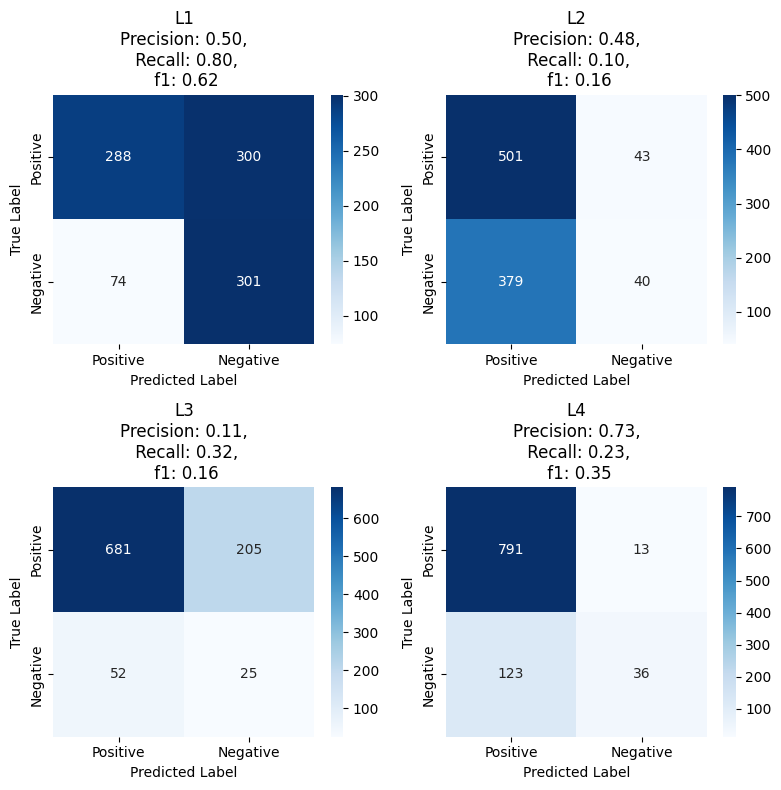

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, label in enumerate(mlb_test.classes_):
    tn, fp, fn, tp = mcm[i].ravel()

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)

    sns.heatmap(mcm[i], annot=True, fmt="d", cmap="Blues", xticklabels=["Positive", "Negative"], yticklabels=["Positive", "Negative"], ax=axes[i])
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")
    axes[i].set_title(f'{label}\nPrecision: {precision:.2f},\n Recall: {recall:.2f},\n f1: {f1:.2f}')

plt.tight_layout()
plt.show()